In [51]:
import pandas as pd
import sqlite3

In [72]:
db_file = "../data/checking-logs.sqlite"
conn = sqlite3.connect(db_file)

Create a graph:
- Analyze only the users, not the admins.
- The font size and fig size are still the same.
- Night is from 0:00:00 to 03:59:59, morning is from 04:00:00 to 09:59:59, afternoon is from 10:00:00 to 16:59:59, and evening is from 17:00:00 to 23:59:59.
- Choose a palette you really enjoy. You do not have to replicate it from the graph above.

In [78]:
query = """
SELECT
    DATE(timestamp) AS date,
    CASE
        WHEN strftime('%H', timestamp) BETWEEN '00' AND '03' THEN 'night'
        WHEN strftime('%H', timestamp) BETWEEN '04' AND '09' THEN 'morning'
        WHEN strftime('%H', timestamp) BETWEEN '10' AND '16' THEN 'afternoon'
        ELSE 'evening'
    END AS daytime,
    COUNT(*) AS commits
FROM checker
WHERE uid LIKE 'user_%'
GROUP BY
    DATE(timestamp),
    CASE
        WHEN strftime('%H', timestamp) BETWEEN '00' AND '03' THEN 'night'
        WHEN strftime('%H', timestamp) BETWEEN '04' AND '09' THEN 'morning'
        WHEN strftime('%H', timestamp) BETWEEN '10' AND '16' THEN 'afternoon'
        ELSE 'evening'
    END;
"""
commits_df = pd.read_sql(query, conn)
print(commits_df)

          date    daytime  commits
0   2020-04-17  afternoon       10
1   2020-04-17    morning       13
2   2020-04-18  afternoon       33
3   2020-04-18    evening       35
4   2020-04-18    morning        1
..         ...        ...      ...
85  2020-05-20    evening       10
86  2020-05-20    morning        7
87  2020-05-21  afternoon       27
88  2020-05-21    evening       21
89  2020-05-21    morning        1

[90 rows x 3 columns]


In [79]:
# Assuming df has columns: date, commits, daytime
pivot_df = commits_df.pivot_table(
    index='date', 
    columns='daytime', 
    values='commits', 
    fill_value=0
)
pivot_df.head()

daytime,afternoon,evening,morning,night
date,,,,
2020-04-17,10.0,0.0,13.0,0.0
2020-04-18,33.0,35.0,1.0,0.0
2020-04-19,16.0,11.0,4.0,2.0
2020-04-20,12.0,13.0,0.0,0.0
2020-04-21,0.0,25.0,0.0,0.0


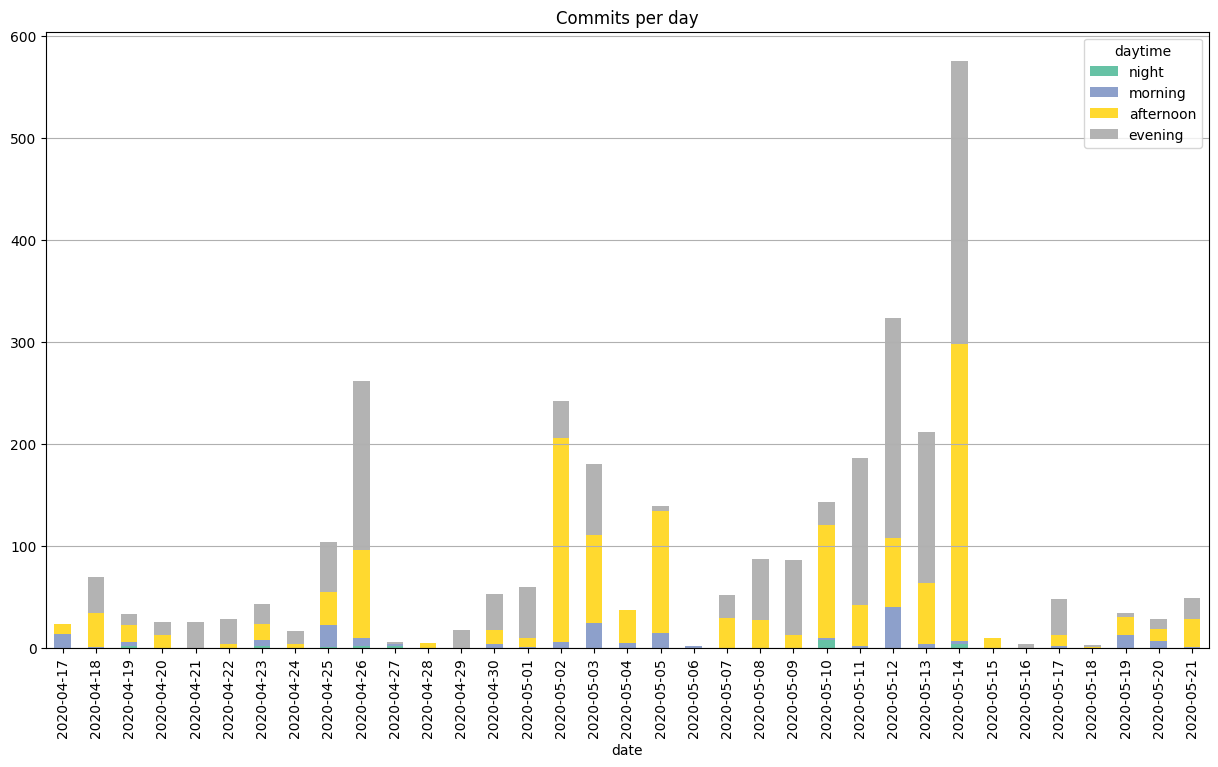

In [83]:
pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(15, 8),
    colormap='Set2',
    title='Commits per day',
    grid=True,
    y=['night','morning', 'afternoon', 'evening']
).grid(axis='x')